Installing Libraries


In [1]:
!pip install pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

Loading dataset

In [2]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-04-20/netflix_titles.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (7787, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


handling missing values

In [3]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB

Missing values:
 show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
des

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,216,492,7769
top,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,1608,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN


In [4]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df = df.dropna(subset=['duration'])   # drops a few corrupted rows

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# duration mixes "90 min" and "3 Seasons" — split into number + unit
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].apply(lambda x: 'min' if 'min' in x else 'Season(s)')

# country / genre are comma-separated lists — take the first as "primary"
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0].strip())
df['primary_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0].strip())

df['gap_years'] = df['year_added'] - df['release_year']

print("Cleaned shape:", df.shape)

Cleaned shape: (7787, 19)


In [5]:
print("Movies:", (df['type']=='Movie').sum())
print("TV Shows:", (df['type']=='TV Show').sum())
print("\nAvg movie duration:", df[df['type']=='Movie']['duration_num'].mean())
print("Top 10 countries:\n", df['primary_country'].value_counts().head(10))
print("\nTop 10 genres:\n", df['primary_genre'].value_counts().head(10))

Movies: 5377
TV Shows: 2410

Avg movie duration: 99.30797842663195
Top 10 countries:
 primary_country
United States     2883
India              956
United Kingdom     577
Unknown            507
Canada             259
Japan              237
France             196
South Korea        194
Spain              168
Mexico             123
Name: count, dtype: int64

Top 10 genres:
 primary_genre
Dramas                      1384
Comedies                    1074
Documentaries                751
Action & Adventure           721
International TV Shows       690
Children & Family Movies     502
Crime TV Shows               369
Kids' TV                     359
Stand-Up Comedy              321
Horror Movies                244
Name: count, dtype: int64


Movies and shows on Netflix

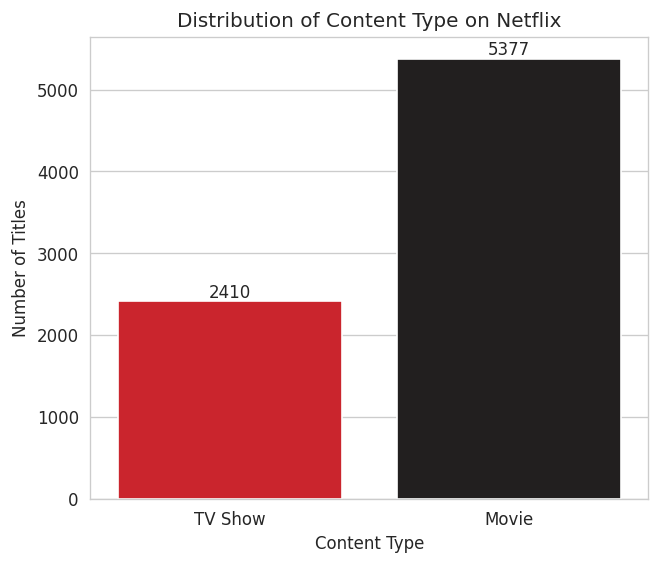

In [6]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df, x='type', hue='type', palette=['#E50914','#221F1F'], legend=False)
ax.set_title('Distribution of Content Type on Netflix')
ax.set_xlabel('Content Type'); ax.set_ylabel('Number of Titles')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

content added on netflix is peak in 2019

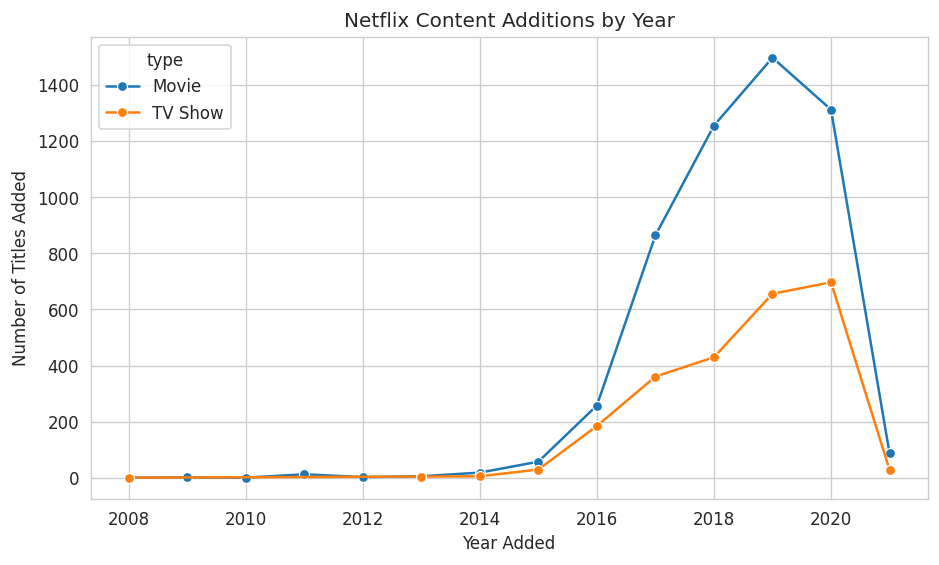

In [7]:
by_year = df.dropna(subset=['year_added']).groupby(['year_added','type']).size().reset_index(name='count')

plt.figure(figsize=(9,5))
sns.lineplot(data=by_year, x='year_added', y='count', hue='type', marker='o')
plt.title('Netflix Content Additions by Year')
plt.xlabel('Year Added'); plt.ylabel('Number of Titles Added')
plt.show()

top 10 countries by no of netflix titles

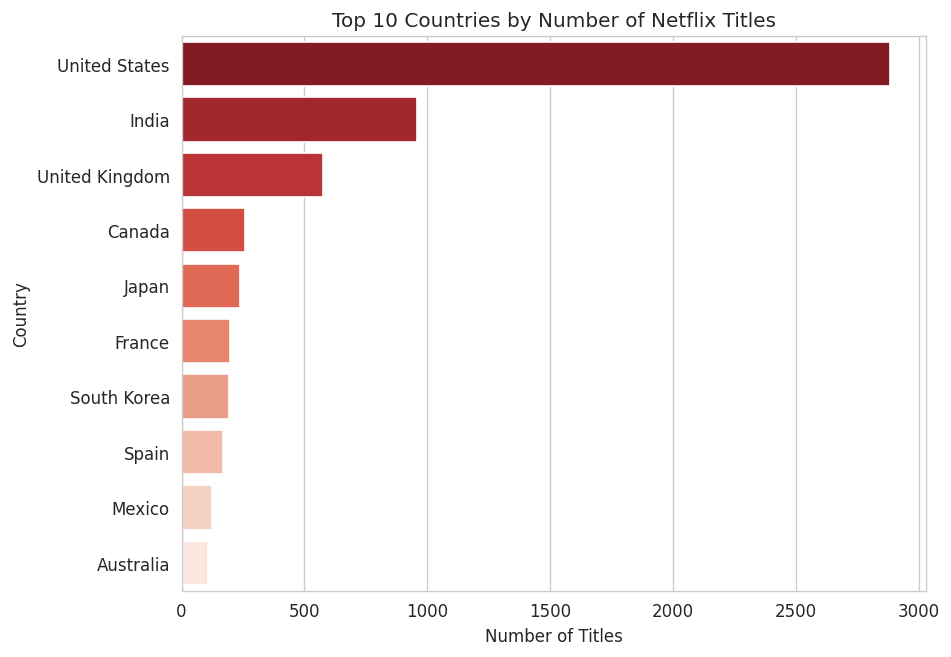

In [8]:
top_countries = df[df['primary_country']!='Unknown']['primary_country'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='Reds_r', legend=False)
plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Number of Titles'); plt.ylabel('Country')
plt.show()

movie duration


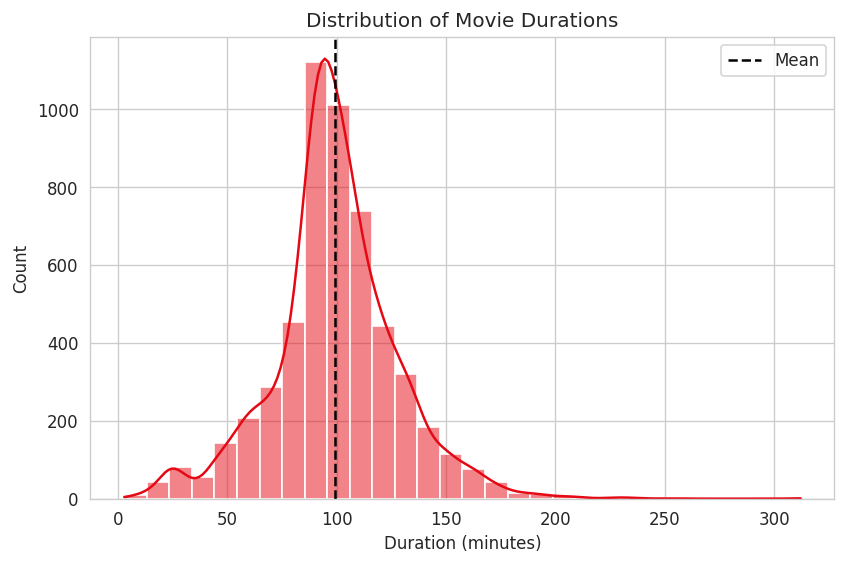

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['type']=='Movie']['duration_num'].dropna(), bins=30, kde=True, color='#E50914')
plt.axvline(df[df['type']=='Movie']['duration_num'].mean(), color='black', linestyle='--', label='Mean')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)'); plt.legend()
plt.show()

categories shows and movies

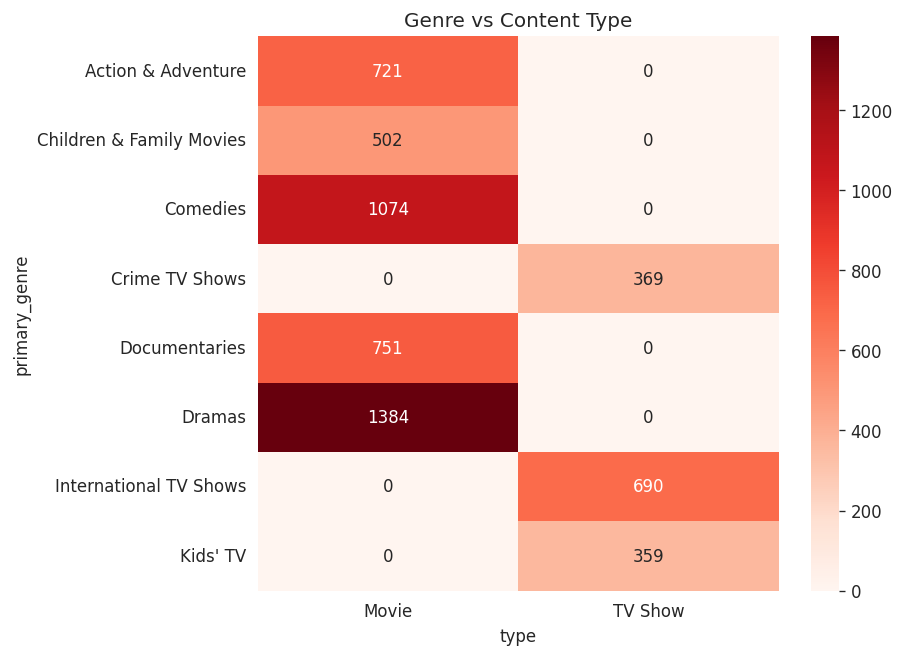

In [10]:
top8 = df['primary_genre'].value_counts().head(8).index
cross = pd.crosstab(df[df['primary_genre'].isin(top8)]['primary_genre'], df['type'])

plt.figure(figsize=(7,6))
sns.heatmap(cross, annot=True, fmt='d', cmap='Reds')
plt.title('Genre vs Content Type')
plt.show()

duration between release and added on netflix

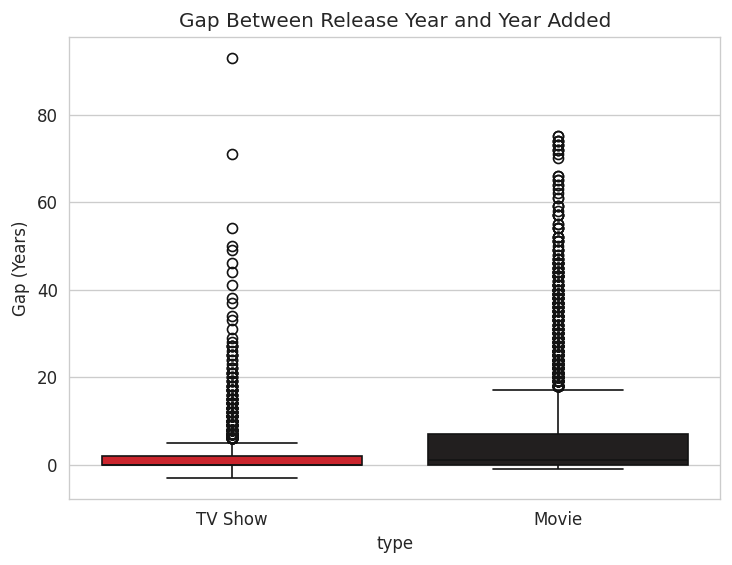

In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='type', y='gap_years', hue='type', palette=['#E50914','#221F1F'], legend=False)
plt.title('Gap Between Release Year and Year Added')
plt.ylabel('Gap (Years)')
plt.show()